# Diffusion-TS Sepsis — Démonstration

Notebook de démonstration du pipeline complet : prétraitement → diffusion semi-supervisée
→ génération synthétique → classification avec incertitude bayésienne.

**Auteurs :** Nadir Nehili, Nahil El Bezzari, Yassine Lazizi, Pascal Le, Anis Melaimi
**Encadrant :** Arthur Satouf
**ING 3 — CY Tech — Generative AI**

---

Ce notebook charge les checkpoints pré-entraînés (`checkpoints/diffusion_best.pt` et
`checkpoints/classifier_best.pt`) et illustre les composantes principales du système
sans ré-entraîner. Pour ré-entraîner depuis zéro :

```bash
uv run python main.py --stage all
```


## 1. Imports et chargement de la configuration

In [1]:
import sys, os
# Ajouter le projet root au path pour les imports src.*
sys.path.insert(0, os.path.abspath(".."))

import json
import yaml
import numpy as np
import torch
import matplotlib.pyplot as plt

from src.models.diffusion_ts import DiffusionTS
from src.models.classifier import SepsisClassifier
from src.data.preprocess import FEATURE_COLS

with open("../configs/config.yaml") as f:
    cfg = yaml.safe_load(f)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {device}")
print(f"Config : label_ratio = {cfg['data']['label_ratio']}, "
      f"n_synthetic_per_real = {cfg['generation']['n_synthetic_per_real']}, "
      f"guidance_scale = {cfg['generation']['guidance_scale']}")


Device : cuda
Config : label_ratio = 0.1, n_synthetic_per_real = 3, guidance_scale = 1.5


## 2. Aperçu du dataset

Le dataset PhysioNet 2019 contient 40 336 patients USI. Après prétraitement
(fenêtres glissantes 24h, stride 6h, normalisation), on obtient 125 988 fenêtres
réparties en train (94 341) / val (12 840) / test (18 807). Le taux de sepsis
au niveau fenêtre est de **2.29 %** — fortement déséquilibré.


In [2]:
data = np.load("../data/processed/splits.npz", allow_pickle=True)
splits = data['splits'].item()
scaler = data['scaler'].item()

print(f"{'Split':<8}{'Fenêtres':>12}{'Sepsis':>10}{'Taux':>8}")
print("-" * 40)
for name in ['train', 'val', 'test']:
    n = splits[name]['X'].shape[0]
    pos = int(splits[name]['y'].sum())
    print(f"{name:<8}{n:>12,}{pos:>10,}{100*pos/n:>7.2f}%")


Split       Fenêtres    Sepsis    Taux
----------------------------------------
train         94,341     2,157   2.29%
val           12,840       316   2.46%
test          18,807       410   2.18%


### 2.1 Visualisation d'une trajectoire patient réelle

Un exemple de patient septique du jeu de train, sur 5 signes vitaux clés.


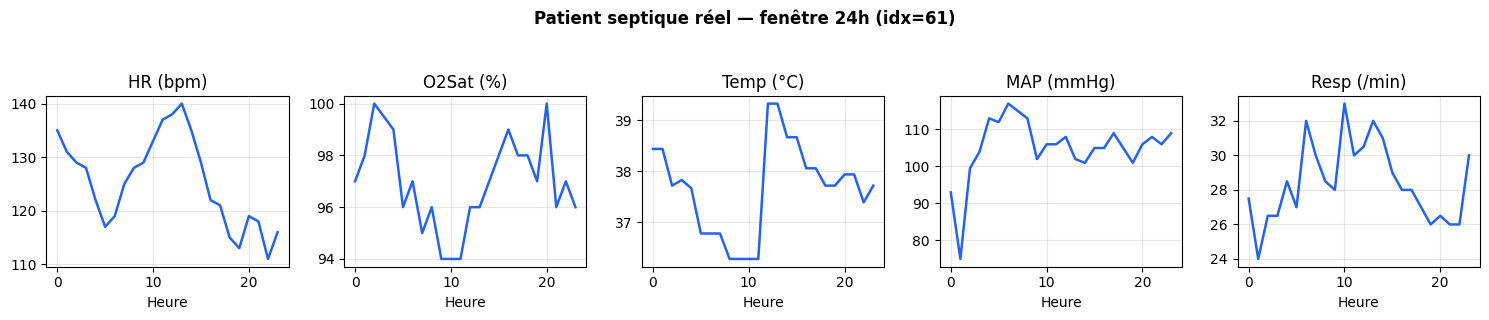

In [3]:
# Premier patient septique du train (dénormalisé)
idx_pos = np.where(splits['train']['y'] == 1)[0][0]
X = splits['train']['X'][idx_pos] * scaler.scale_ + scaler.mean_  # (24, 40)

key = ['HR', 'O2Sat', 'Temp', 'MAP', 'Resp']
key_idx = [FEATURE_COLS.index(f) for f in key]
units = {'HR': 'bpm', 'O2Sat': '%', 'Temp': '°C', 'MAP': 'mmHg', 'Resp': '/min'}

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, (f, fi) in enumerate(zip(key, key_idx)):
    axes[i].plot(X[:, fi], color="#2563EB", lw=1.8)
    axes[i].set_title(f"{f} ({units[f]})")
    axes[i].set_xlabel("Heure")
    axes[i].grid(alpha=0.3)
fig.suptitle(f"Patient septique réel — fenêtre 24h (idx={idx_pos})", y=1.05, fontweight="bold")
plt.tight_layout()
plt.show()


## 3. Modèle de diffusion (Diffusion-TS)

On charge le modèle pré-entraîné. Il a été entraîné sur les 94 341 fenêtres
du train (sepsis labellés, sepsis non labellés et tous les sains), 100 epochs,
schedule cosinus.

À l'inférence avec `generate_class(label=1, ...)` et Classifier-Free Guidance
(γ = 1.5), il produit des trajectoires synthétiques étiquetées sepsis.


In [4]:
diffusion = DiffusionTS(cfg).to(device)
diffusion.load_state_dict(torch.load("../checkpoints/diffusion_best.pt", map_location=device))
diffusion.eval()
print("Diffusion-TS chargé.")
n_params = sum(p.numel() for p in diffusion.parameters())
print(f"Paramètres : {n_params/1e6:.2f} M")


Diffusion-TS chargé.
Paramètres : 0.63 M


### 3.1 Génération de 4 trajectoires synthétiques de sepsis

DDIM, 50 pas de débruitage.


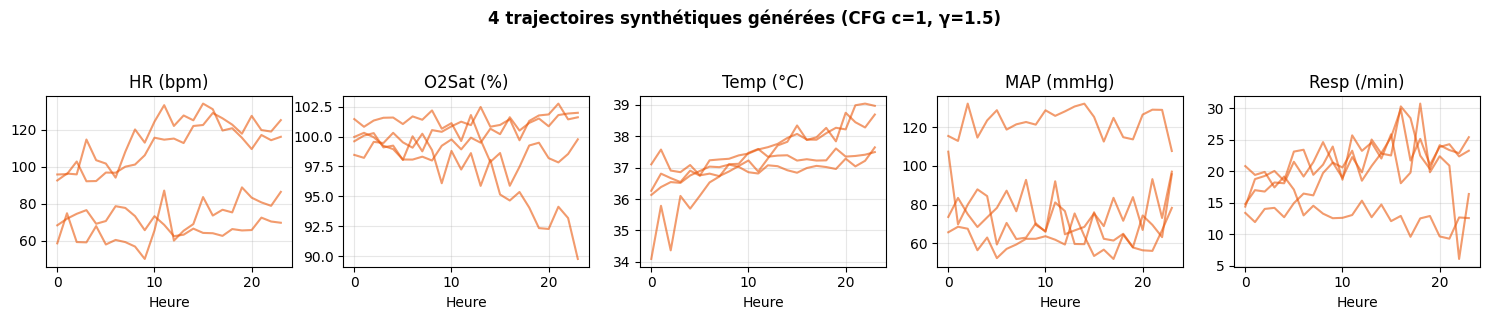

In [5]:
torch.manual_seed(0)
synth = diffusion.generate_class(label=1, n_samples=4, device=device, fast=True, n_ddim_steps=50)
synth = synth.cpu().numpy()
synth_d = synth * scaler.scale_ + scaler.mean_

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, (f, fi) in enumerate(zip(key, key_idx)):
    for k in range(4):
        axes[i].plot(synth_d[k, :, fi], color="#EA580C", alpha=0.6, lw=1.5)
    axes[i].set_title(f"{f} ({units[f]})")
    axes[i].set_xlabel("Heure")
    axes[i].grid(alpha=0.3)
fig.suptitle("4 trajectoires synthétiques générées (CFG c=1, γ=1.5)", y=1.05, fontweight="bold")
plt.tight_layout()
plt.show()


## 4. Classifieur Transformer + MC Dropout

Le classifieur a été entraîné sur 98 870 fenêtres (215 sepsis labellés réels +
6 471 sepsis synthétiques + 92 184 sains), avec class-balanced loss et
early stopping sur l'AUROC validation (epoch 8 / 50).

À l'inférence, on garde le Dropout actif et on fait 50 passes Monte Carlo :
- Moyenne des 50 sorties → **probabilité de sepsis**
- Variance des 50 sorties → **score d'incertitude**


In [6]:
diff_cfg = cfg["diffusion"]
clf_cfg = cfg["classifier"]
classifier = SepsisClassifier(
    n_features=diff_cfg["n_features"],
    seq_len=diff_cfg["seq_len"],
    d_model=clf_cfg["d_model"],
    n_heads=clf_cfg["n_heads"],
    n_layers=clf_cfg["n_layers"],
    d_ff=clf_cfg["d_ff"],
    dropout=clf_cfg["dropout"],
).to(device)
classifier.load_state_dict(torch.load("../checkpoints/classifier_best.pt", map_location=device))
print("Classifieur chargé.")
n_params_clf = sum(p.numel() for p in classifier.parameters())
print(f"Paramètres : {n_params_clf/1e6:.2f} M")


Classifieur chargé.
Paramètres : 0.42 M


### 4.1 Prédiction sur 4 cas représentatifs du test set

On prend les indices identifiés précédemment :
- **TP confiant** (idx 153) — vrai sepsis, modèle confiant
- **TN confiant** (idx 11930) — vrai sain, modèle confiant
- **FP incertain** (idx 4136) — faux positif MAIS variance élevée → MC Dropout détecte le doute
- **FN silencieux** (idx 16786) — sepsis raté, variance basse (limite du modèle)


In [7]:
# Charger les prédictions déjà calculées
y_true = np.load("../results/y_true.npy")
mean_prob = np.load("../results/mean_prob.npy")
unc = np.load("../results/uncertainty.npy")
with open("../results/metrics.json") as f:
    metrics = json.load(f)
threshold = metrics["threshold"]
print(f"Seuil opérationnel (Youden) : {threshold:.4f}\n")

cases = [
    ("TP confiant",   153),
    ("TN confiant",   11930),
    ("FP incertain",  4136),
    ("FN silencieux", 16786),
]
print(f"{'Cas':<16}{'idx':>7}{'y_true':>9}{'P(sepsis)':>12}{'Var x1e3':>12}{'Décision':>14}")
print("-" * 75)
for name, idx in cases:
    decision = "SEPSIS" if mean_prob[idx] >= threshold else "non-sepsis"
    correct = "✓" if (mean_prob[idx] >= threshold) == bool(y_true[idx]) else "✗"
    print(f"{name:<16}{idx:>7}{int(y_true[idx]):>9}{mean_prob[idx]:>12.4f}"
          f"{unc[idx]*1000:>12.4f}{decision+' '+correct:>14}")


Seuil opérationnel (Youden) : 0.0178

Cas                 idx   y_true   P(sepsis)    Var x1e3      Décision
---------------------------------------------------------------------------
TP confiant         153        1      0.4193      1.0747      SEPSIS ✓
TN confiant       11930        0      0.0018      0.0009  non-sepsis ✓
FP incertain       4136        0      0.7279     19.4830      SEPSIS ✗
FN silencieux     16786        1      0.0133      0.1192  non-sepsis ✗


**Lecture clinique :**

- Le **TP confiant** est correctement détecté avec faible incertitude.
- Le **FP incertain** est l'exemple-clé du projet : le modèle se trompe (le patient n'a pas de sepsis), mais sa variance MC Dropout est ~20× plus élevée que celle d'un cas confiant. Un système clinique pourrait classer cette alerte en **"à vérifier"** plutôt qu'en alarme automatique.
- Le **FN silencieux** illustre la limite : le modèle rate le sepsis ET ne le sait pas (variance basse). Cas typique : présentation atypique (ici hypothermie 35 °C au lieu de fièvre).


## 5. Métriques globales sur le test set


In [8]:
print("Métriques sur le test set (18 807 fenêtres, 2.18 % positifs) :\n")
print(f"  AUROC                              : {metrics['auroc']:.4f}")
print(f"  AUPRC                              : {metrics['auprc']:.4f}")
print(f"  F1 (au seuil Youden = {metrics['threshold']:.4f}) : {metrics['f1']:.4f}")
print(f"  Brier score                        : {metrics['brier']:.4f}")
print(f"  ECE (Expected Calibration Error)   : {metrics['ece']:.4f}")
print(f"  PhysioNet utility (notre formule)  : {metrics['physionet_utility']:.4f}")
print(f"\nCorrélation incertitude-erreur     : {metrics['corr_uncertainty_error']:.3f}")
print(f"Variance MC sur prédictions correctes : {metrics['uncertainty_correct']*1000:.4f} (×10⁻³)")
print(f"Variance MC sur prédictions erreurs   : {metrics['uncertainty_incorrect']*1000:.4f} (×10⁻³)")
ratio = metrics['uncertainty_incorrect'] / metrics['uncertainty_correct']
print(f"Ratio variance erreurs / corrects     : ×{ratio:.1f}")


Métriques sur le test set (18 807 fenêtres, 2.18 % positifs) :

  AUROC                              : 0.8679
  AUPRC                              : 0.1363
  F1 (au seuil Youden = 0.0178) : 0.1139
  Brier score                        : 0.0203
  ECE (Expected Calibration Error)   : 0.0088
  PhysioNet utility (notre formule)  : -0.0801

Corrélation incertitude-erreur     : 0.258
Variance MC sur prédictions correctes : 0.2116 (×10⁻³)
Variance MC sur prédictions erreurs   : 1.3916 (×10⁻³)
Ratio variance erreurs / corrects     : ×6.6


## 6. Conclusion

Ce notebook a illustré le pipeline complet de Diffusion-TS Sepsis :

1. **Données** : 125 988 fenêtres de 24h, 2.29 % de positifs (très déséquilibré).
2. **Diffusion** : entraînée semi-supervisé sur toutes les données, génère ensuite 6 471 trajectoires synthétiques de sepsis.
3. **Classifieur** : entraîné sur le dataset augmenté, produit P(sepsis) + variance MC Dropout.
4. **Performance** : AUROC = 0.868, AUPRC = 0.136, ECE = 0.009, Util = −0.080. Variance MC Dropout ×6.6 sur les erreurs (incertitude calibrée).

**Pour aller plus loin :**
- Voir le rapport `rapport.pdf` pour la discussion complète des résultats et des limitations.
- Voir `figures/synthetic_vs_real.pdf` pour la comparaison visuelle réels/synthétiques sur 6 cas.
- Voir `figures/abstention.pdf` pour la stratégie d'abstention basée sur l'incertitude.

**Code :** [github.com/BigYellowData/diffusion-ts-sepsis](https://github.com/BigYellowData/diffusion-ts-sepsis)
